Epoch 1/5 | Train Loss: 0.8703
Epoch 2/5 | Train Loss: 0.5761
Epoch 3/5 | Train Loss: 0.4859
Epoch 4/5 | Train Loss: 0.4299
Epoch 5/5 | Train Loss: 0.3832
Saved model to: outputs/model.pt
Test Loss: 0.3881 | Test Accuracy: 83.91%


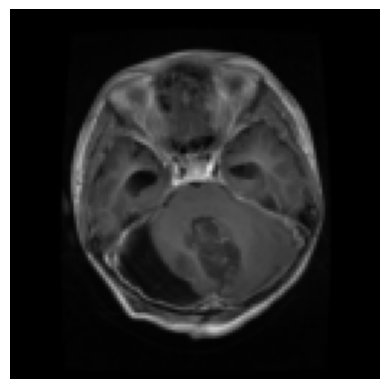

Pred: meningioma Confidence: 0.47268688678741455 GT: glioma


In [1]:
import torch
from src.data_loader import get_dataloaders
from src.model import create_model
from src.optimizer import get_optimizer_and_loss
from src.train import train_model
from src.evaluate import evaluate_model
from src.predict import predict_one, show_image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_dl, test_dl = get_dataloaders("data/Training", "data/Testing")
class_names = test_dl.dataset.classes

model = create_model().to(device)
loss_fn, opt = get_optimizer_and_loss(model)

train_model(model, train_dl, loss_fn, opt, device, epochs=5)
evaluate_model(model, test_dl, loss_fn, device)

img, label = test_dl.dataset[0]
show_image(img)
pred_class, conf, _ = predict_one(model, img, class_names, device)
print("Pred:", pred_class, "Confidence:", conf, "GT:", class_names[label])
